In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
from MoviDataset import MoviDataset
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision import io
import torch
path='/home/nfs/inf6/data/datasets/MOVi/movi_c/'
video_dataset= MoviDataset(path,split='validation') 
BATCH_SIZE = 32
video_loader = DataLoader(dataset=video_dataset, 
                          batch_size=BATCH_SIZE,
                          shuffle=False)

Data Loaded:
   Coordinates: 250   Masks: 250   RGB videos:  250   Flows:  250


### Images

In [17]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/rgb_00208_07.png'
rgb_image = io.read_image(path=path).to(torch.float32)
rgb_image.shape

torch.Size([3, 128, 128])

### Flow

In [ ]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/flow_00208_07.png'
flow = io.read_image(path=path).to(torch.float32)
flow.shape

torch.Size([3, 128, 128])

### Masks

In [ ]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_00000.pt'
mask = torch.load(path, map_location="cpu")
mask['masks'].shape


torch.Size([24, 128, 128])

In [11]:
print(mask['masks'].shape)
print(mask['masks'].unique())

torch.Size([24, 128, 128])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)


In [18]:
mask['masks'][9]

tensor([[0, 0, 2,  ..., 0, 0, 0],
        [0, 0, 2,  ..., 0, 0, 0],
        [0, 0, 2,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

### Coordinates

In [13]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/coords_00236.pt'
coord = torch.load(path, map_location="cpu")
print("Keys in loaded coord dict:", coord.keys())
print("Shape of coord['com']:", coord['com'].shape)
print("Shape of coord['bbox']:", coord['bbox'].shape)

Keys in loaded coord dict: dict_keys(['com', 'bbox'])
Shape of coord['com']: torch.Size([24, 11, 2])
Shape of coord['bbox']: torch.Size([24, 11, 4])


### Data Visualization

60
BATCH Video number: 1, read frames count: 24


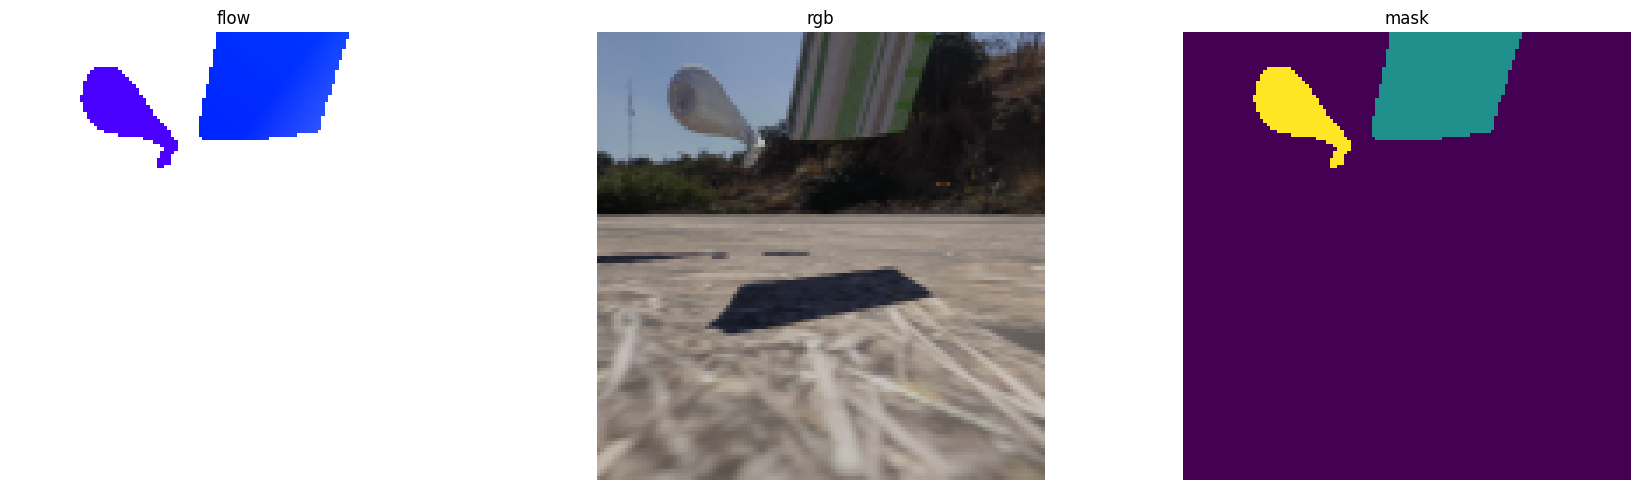

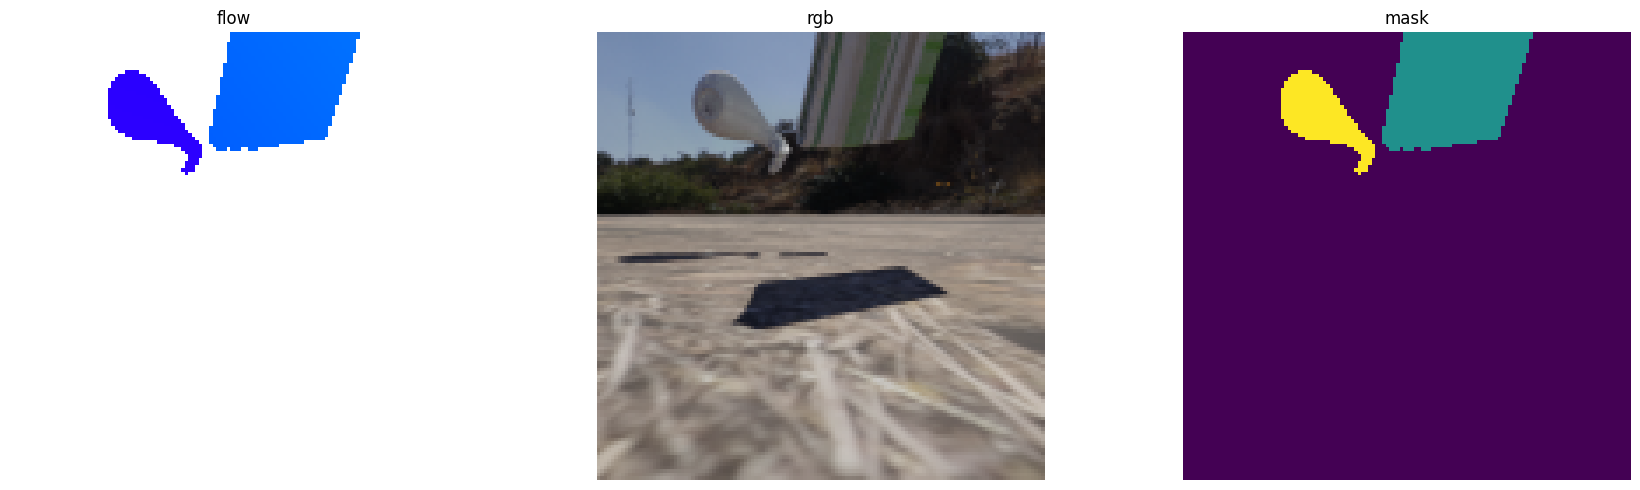

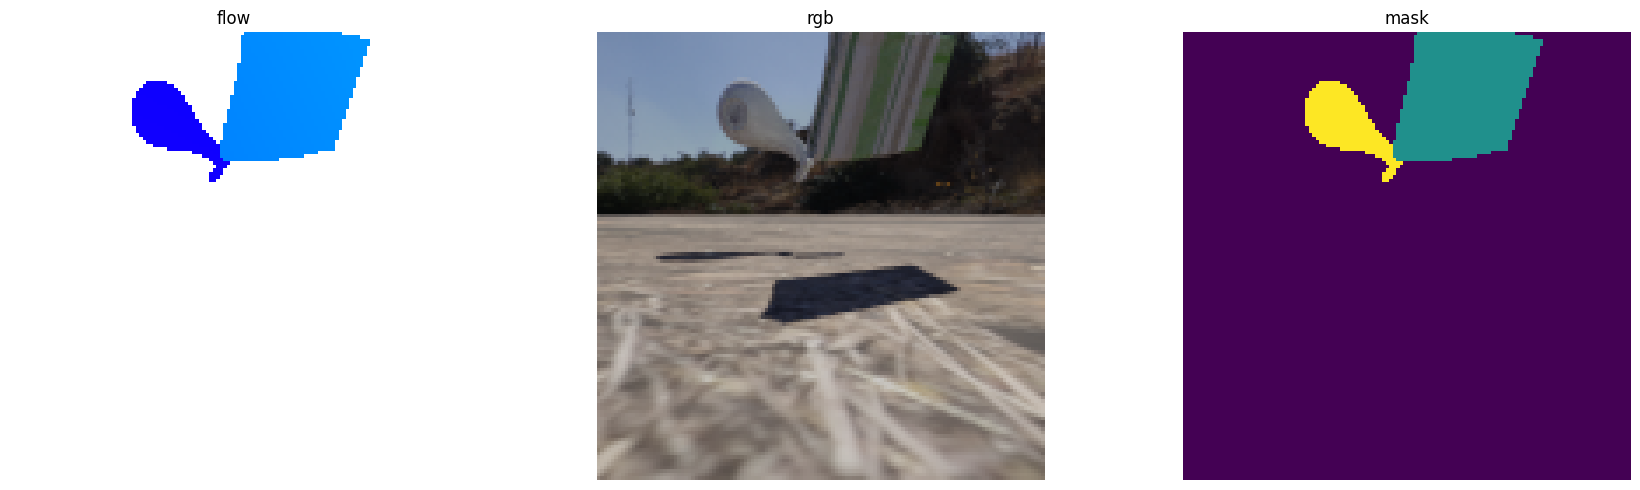

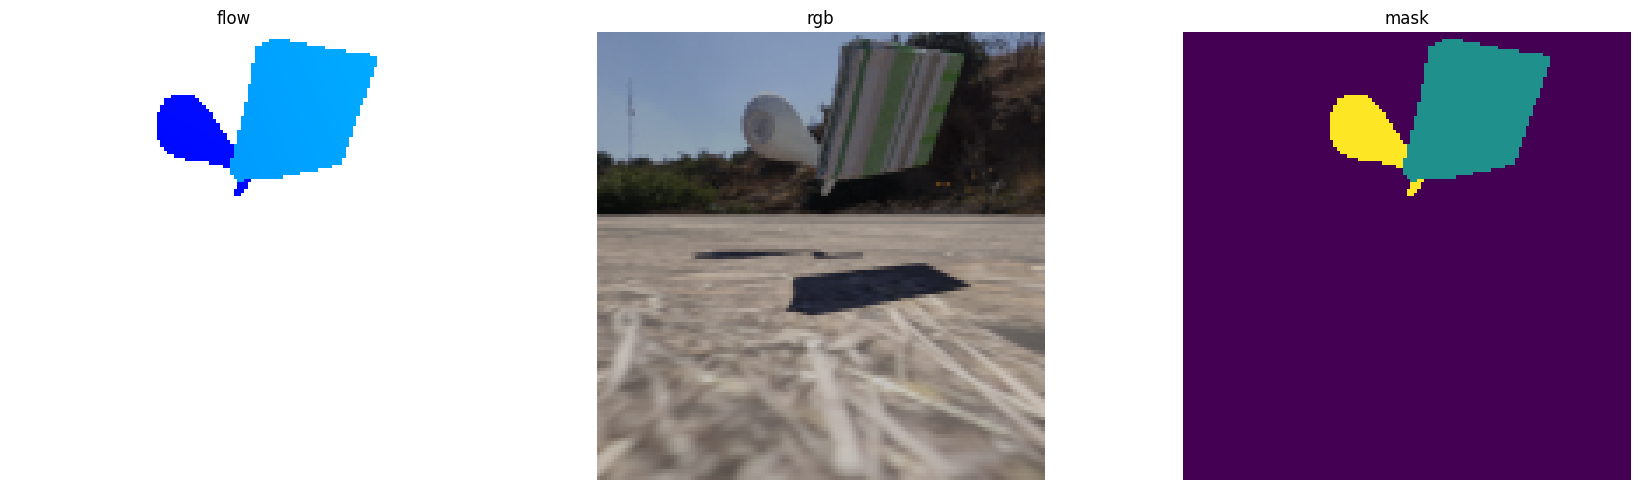

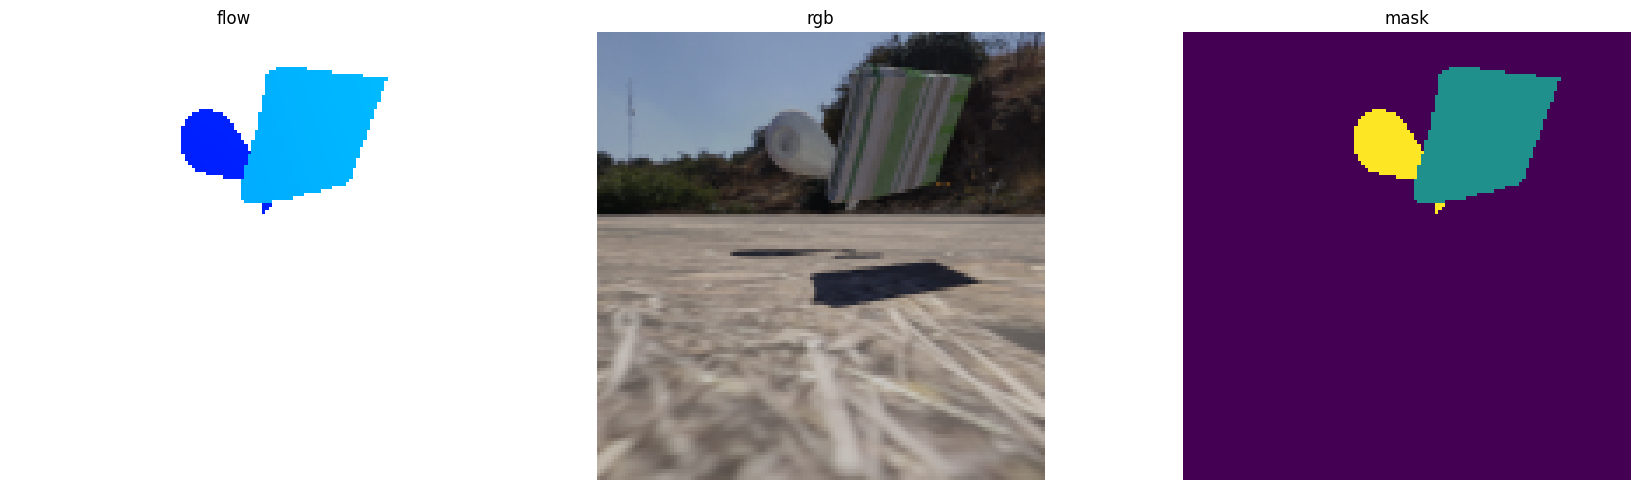

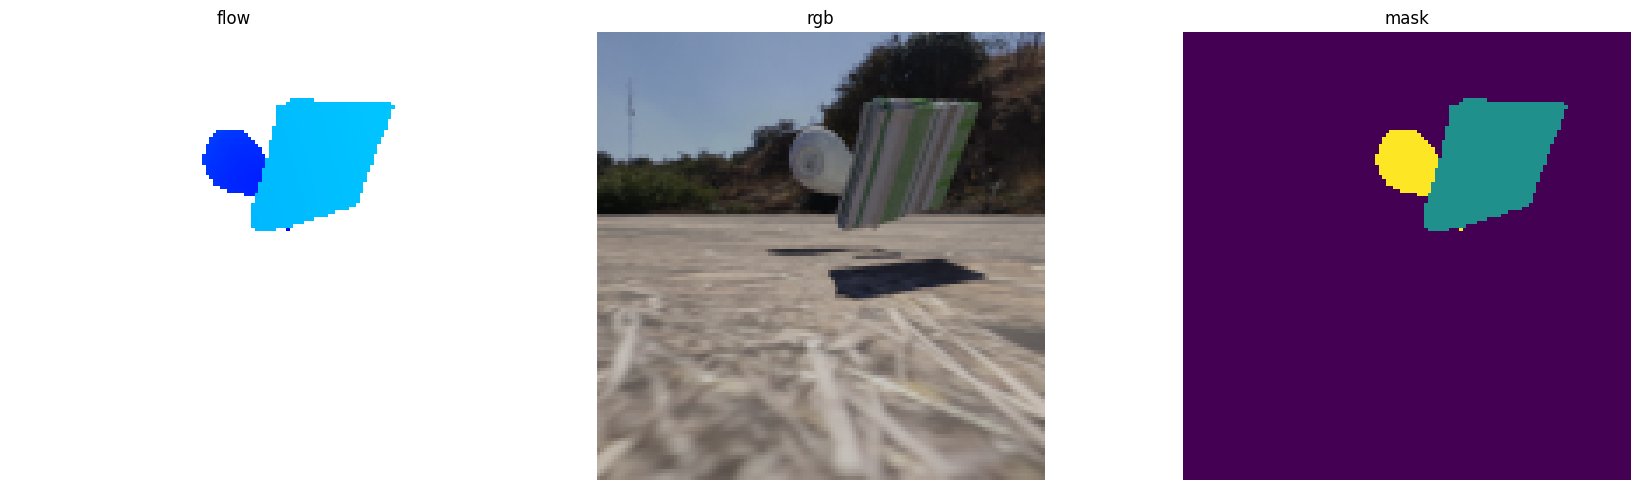

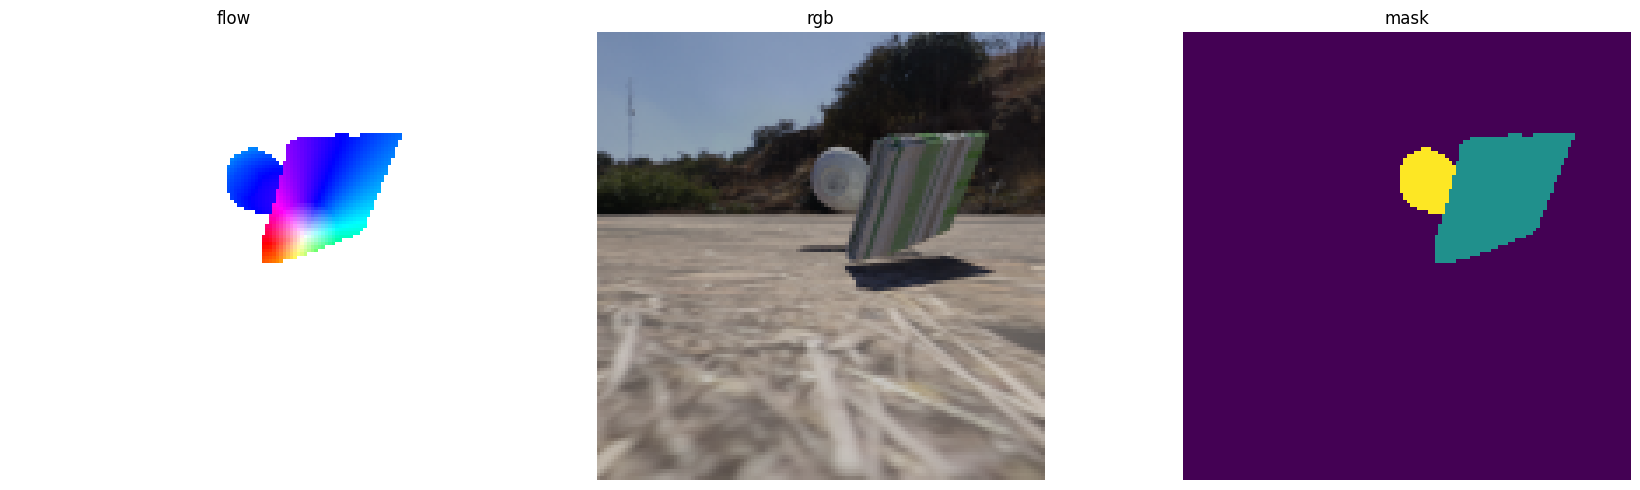

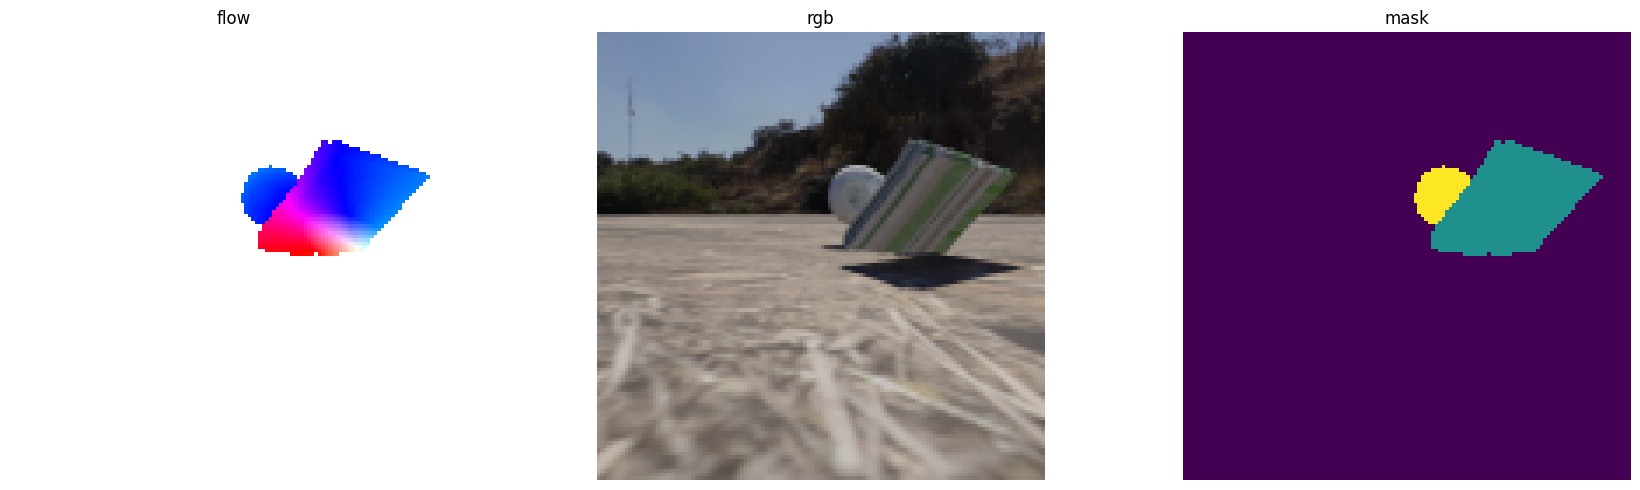

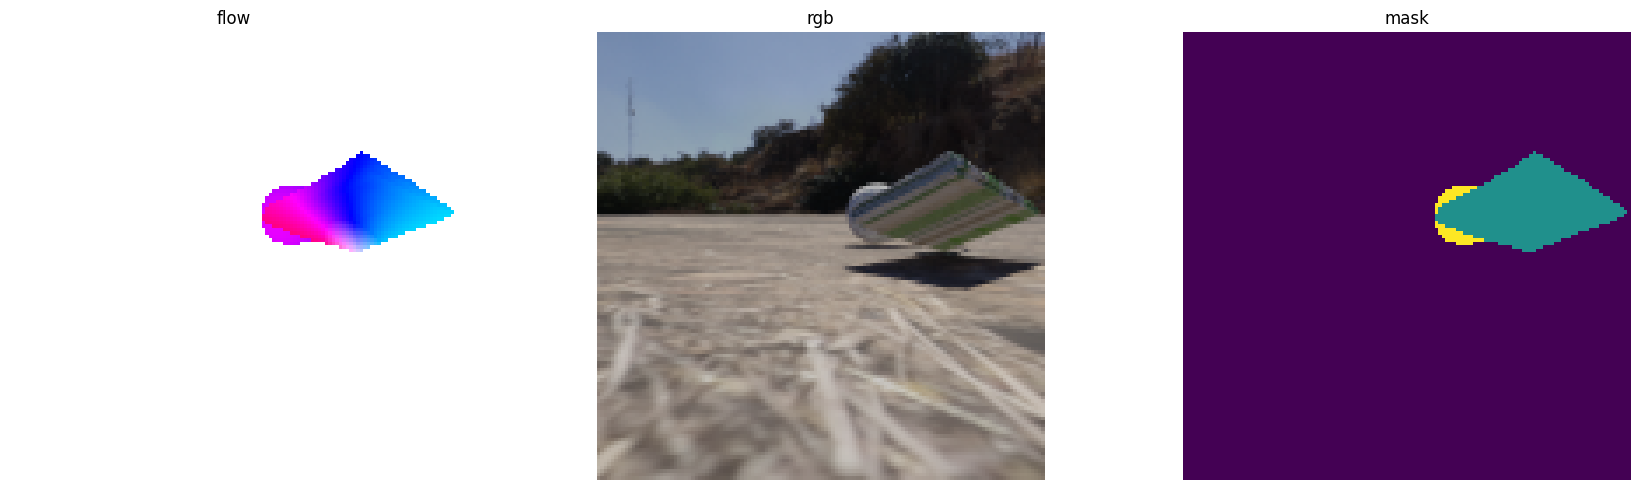

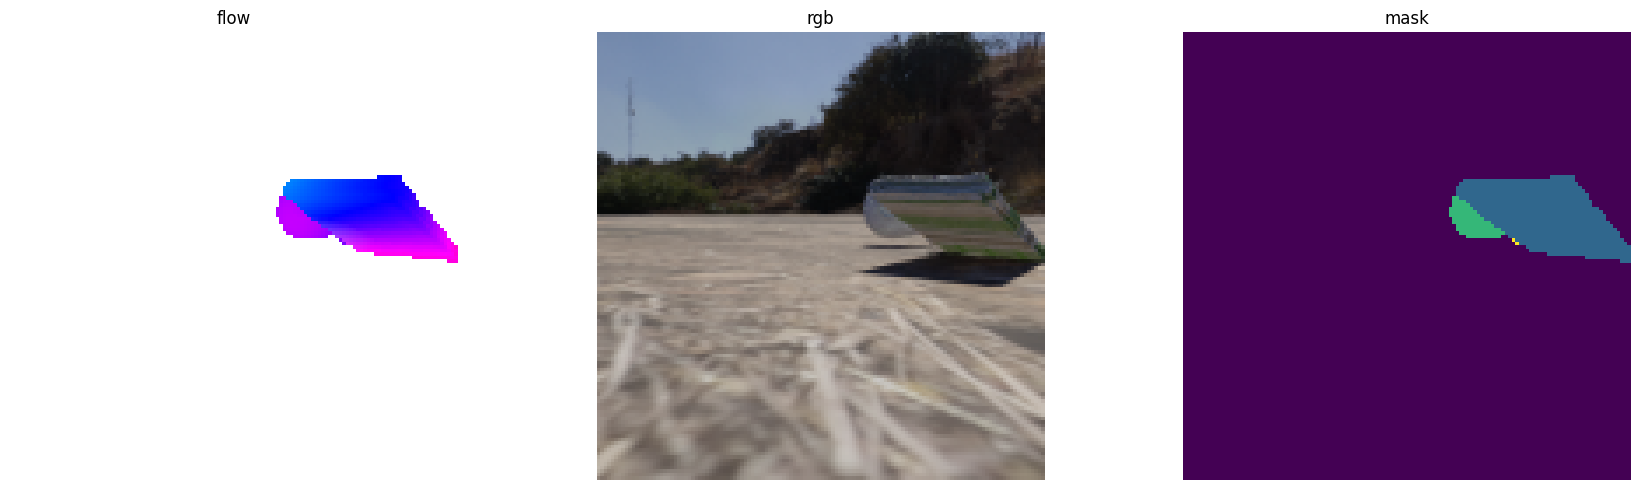

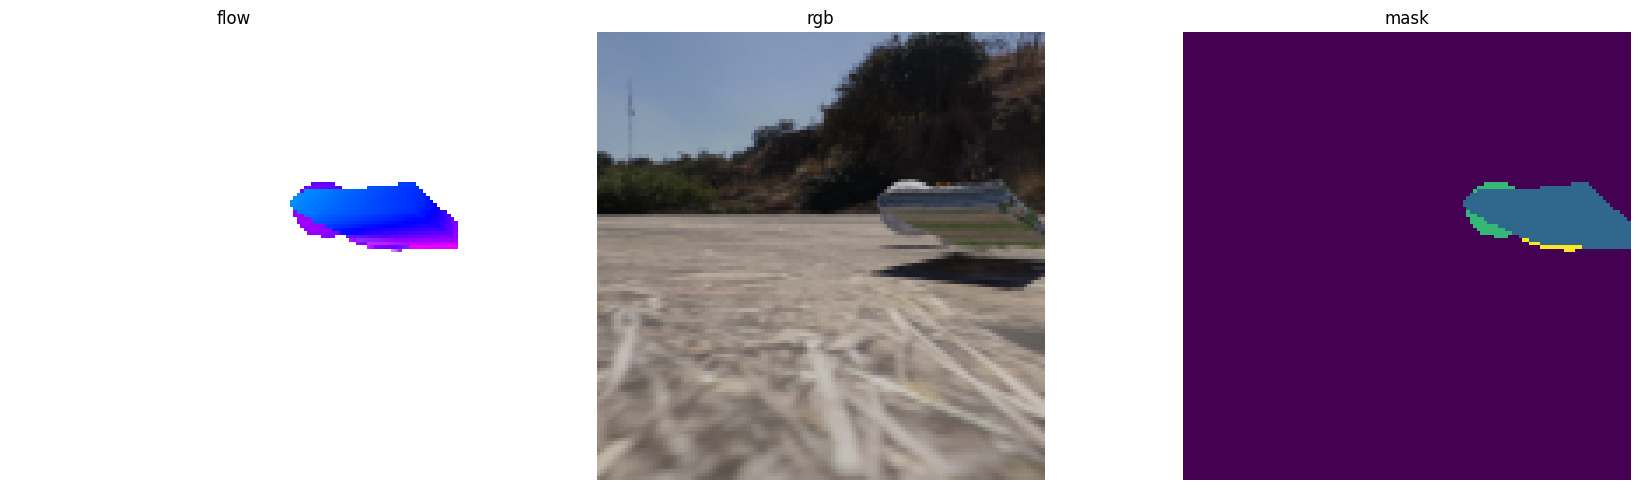

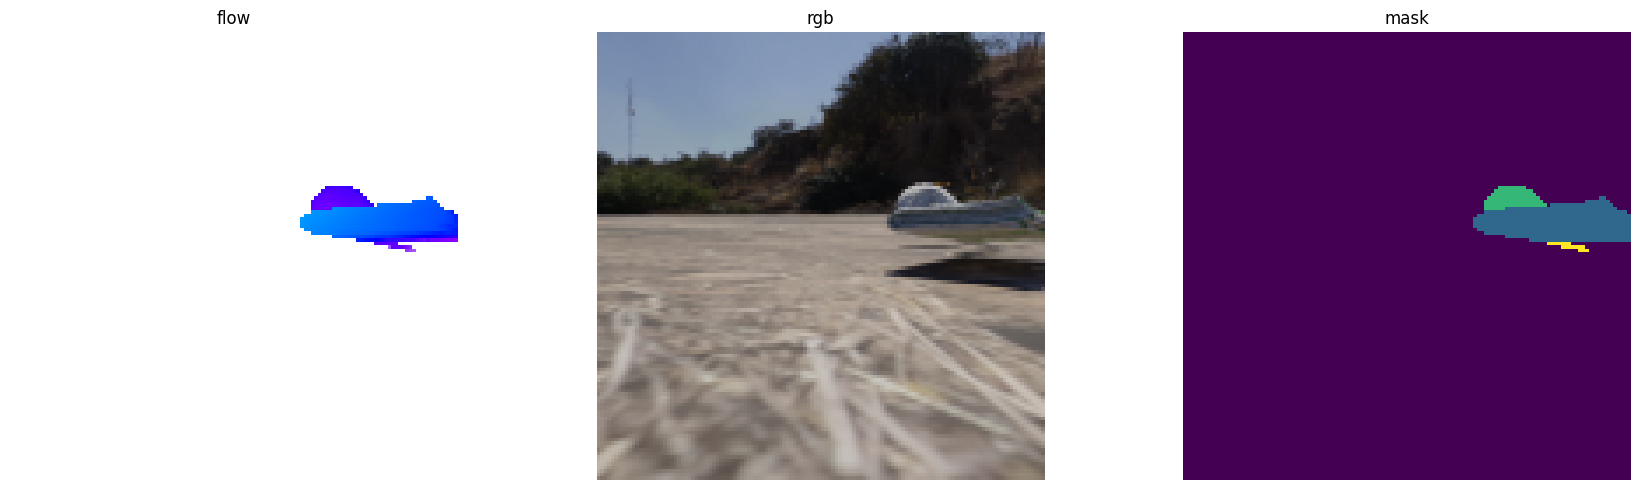

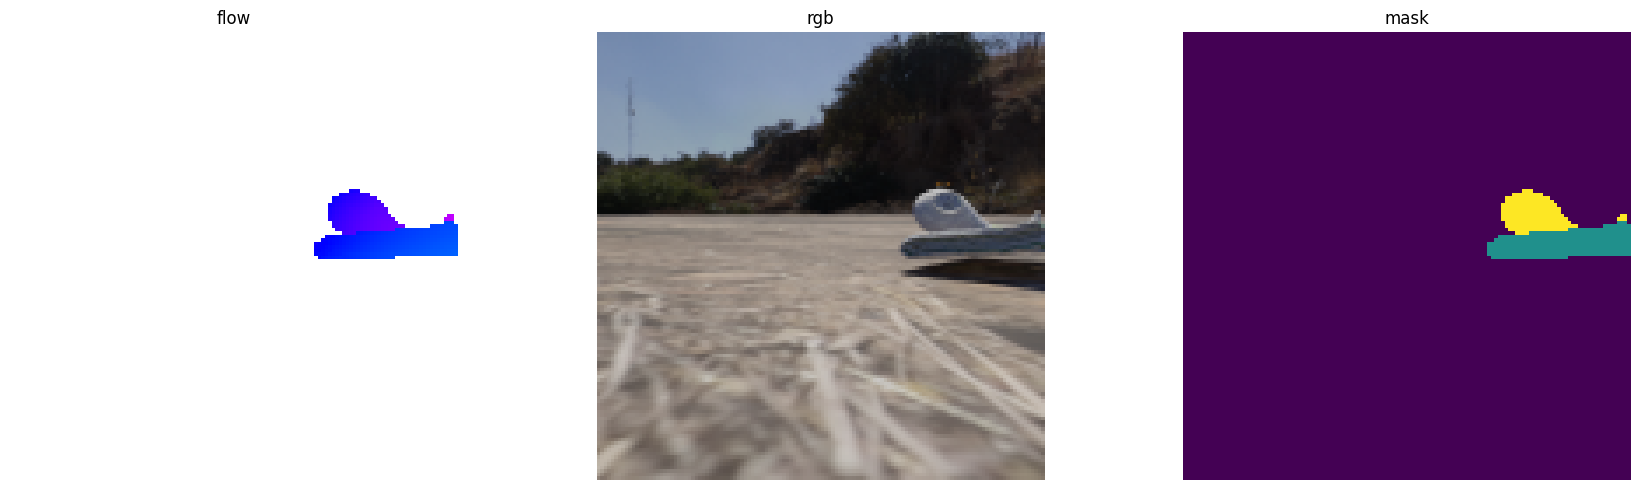

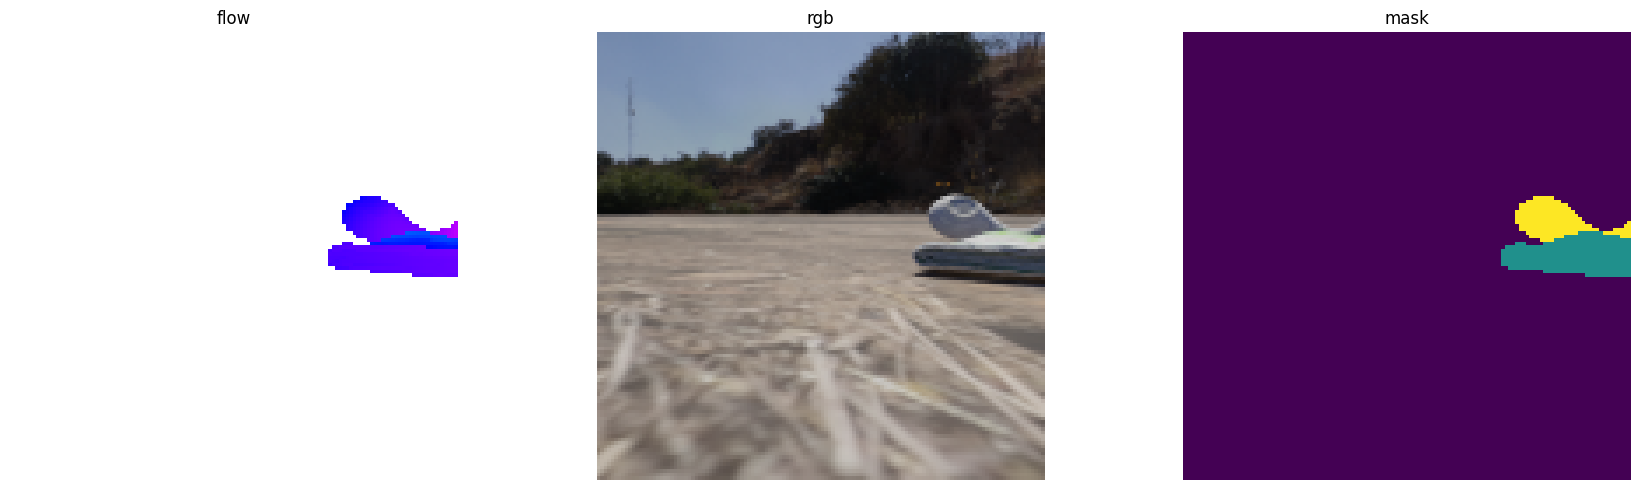

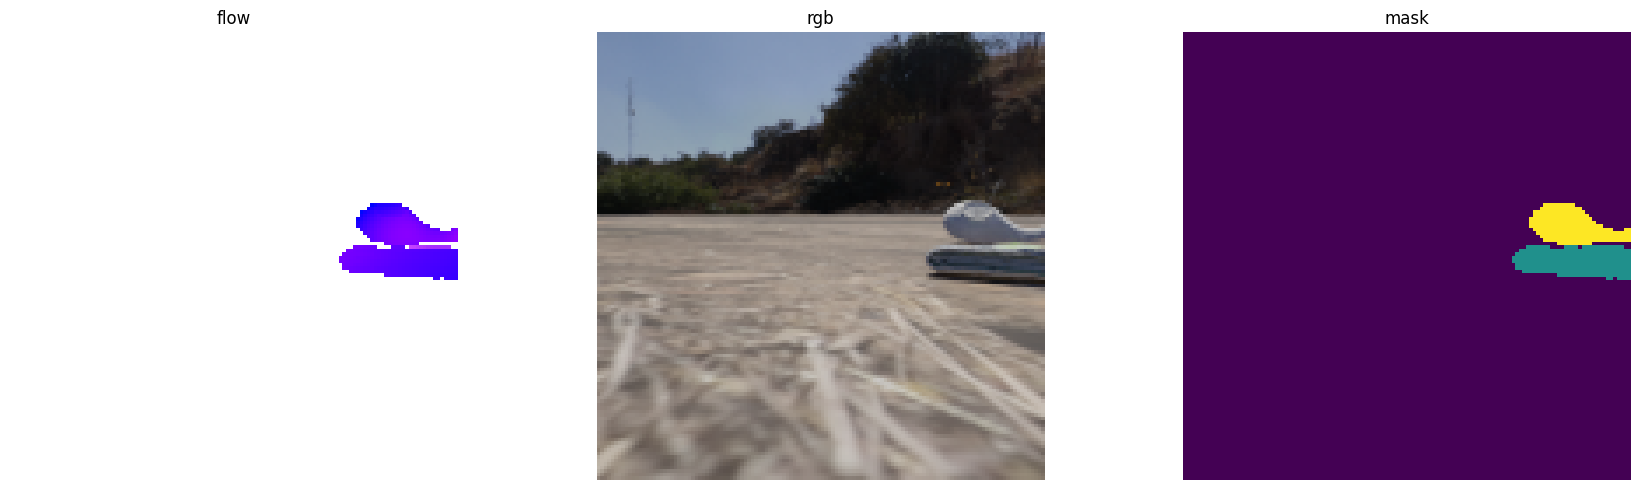

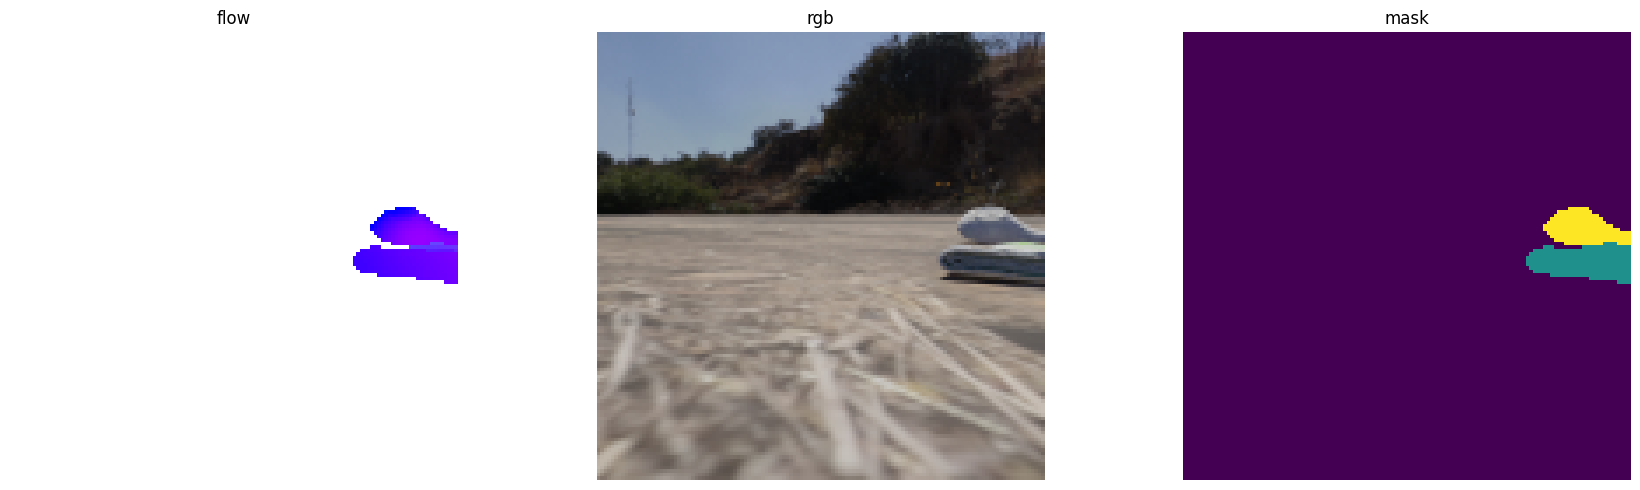

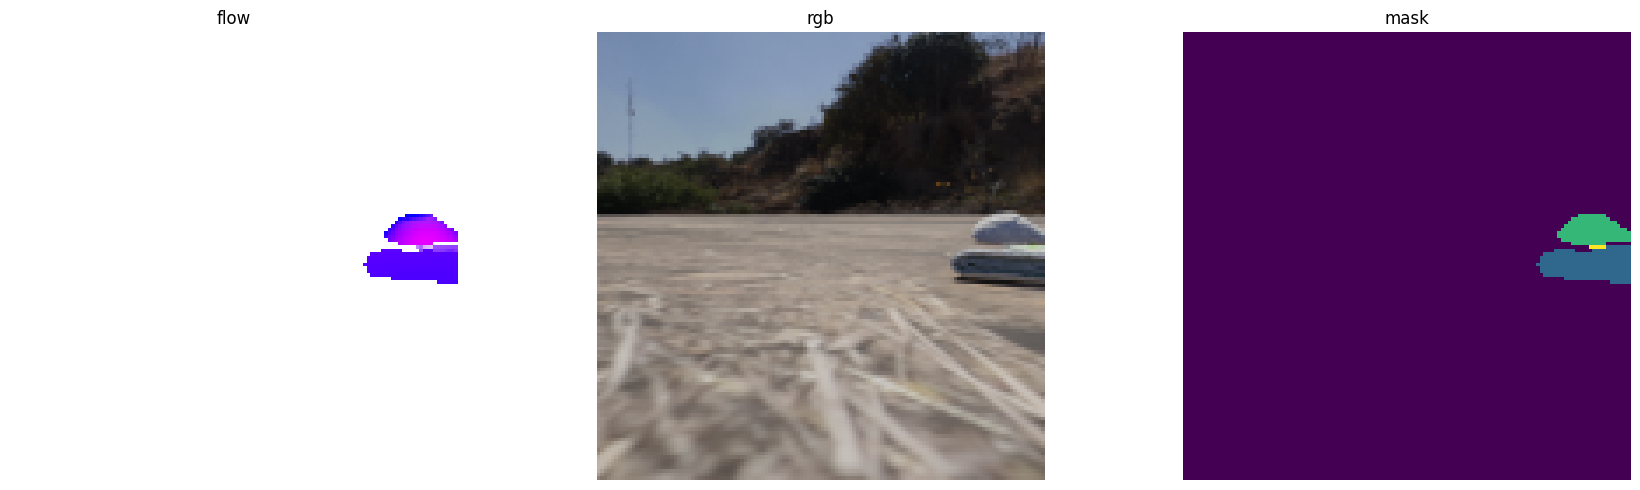

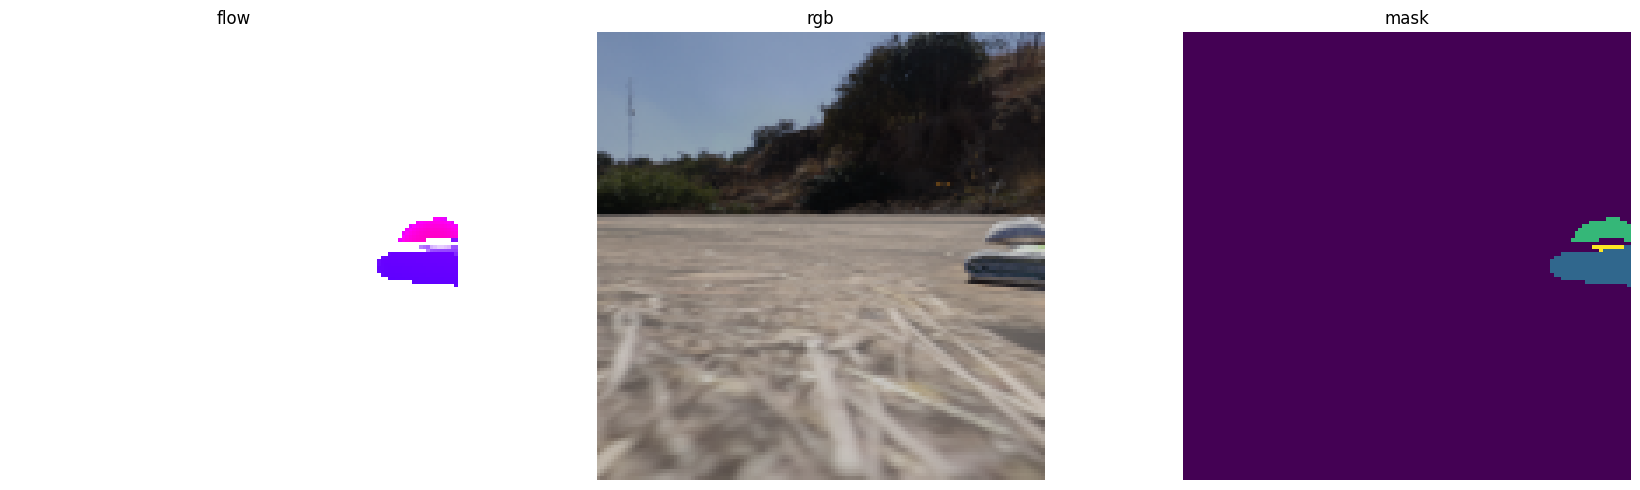

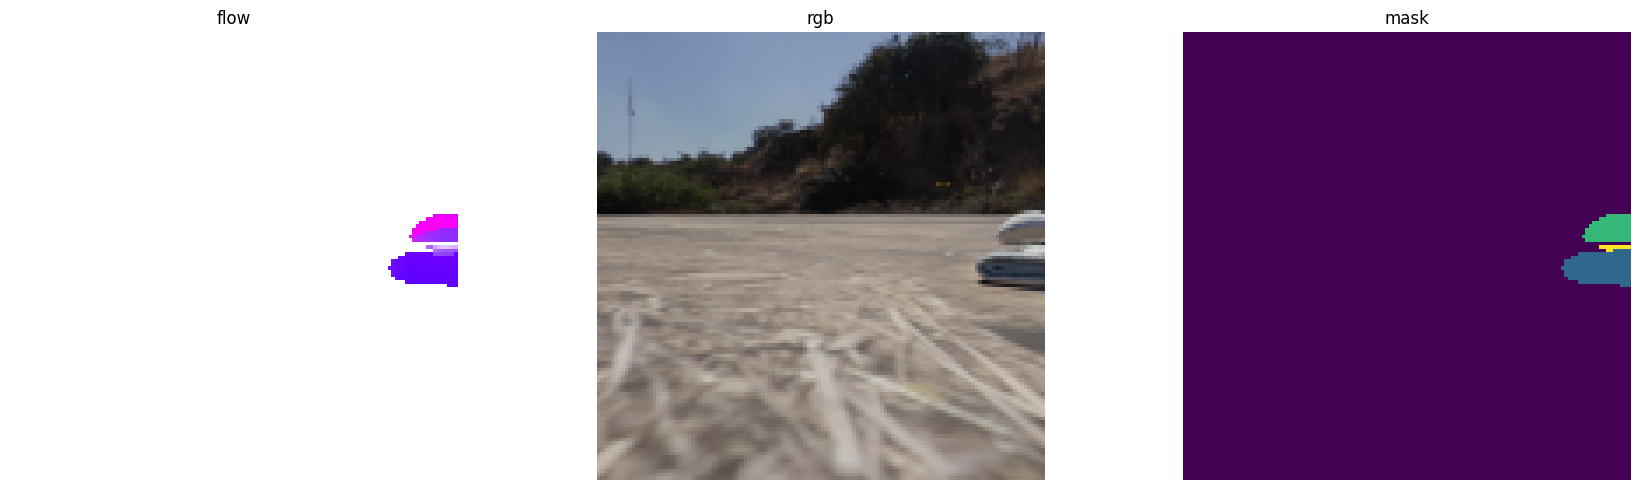

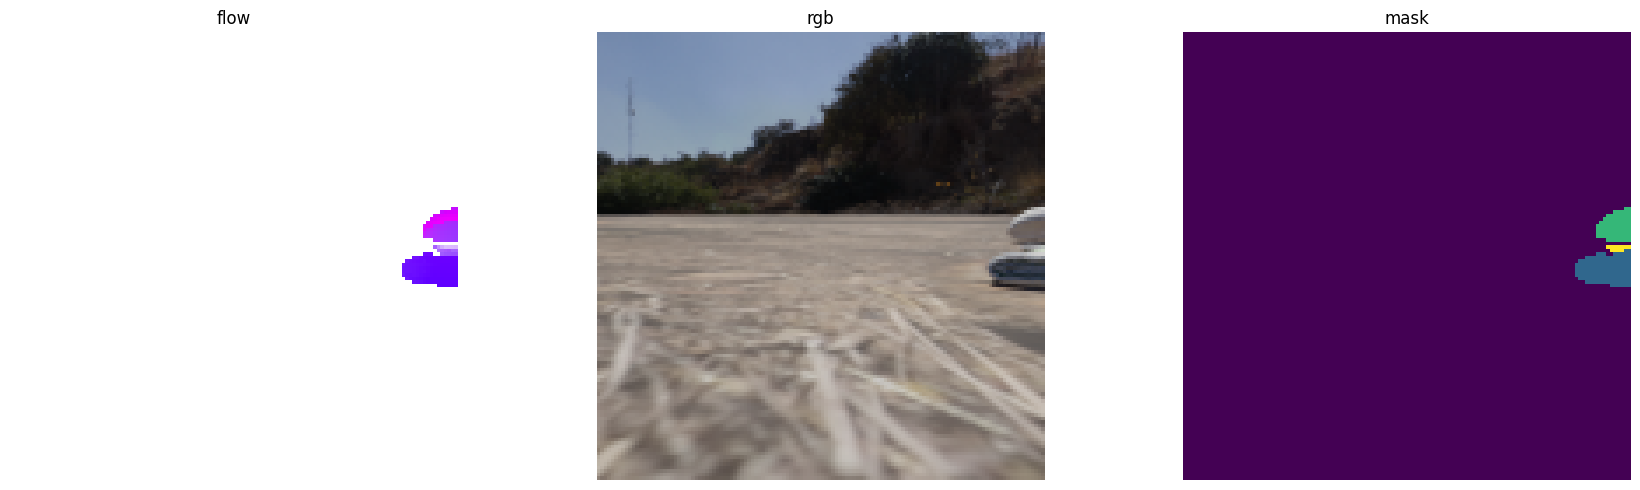

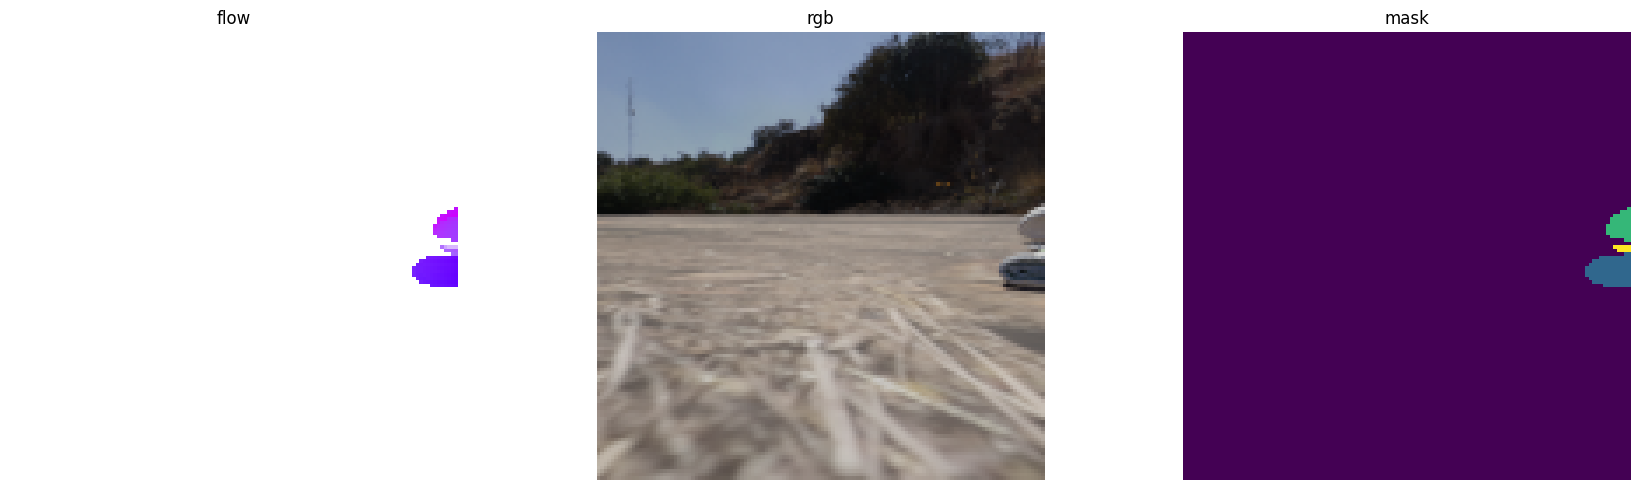

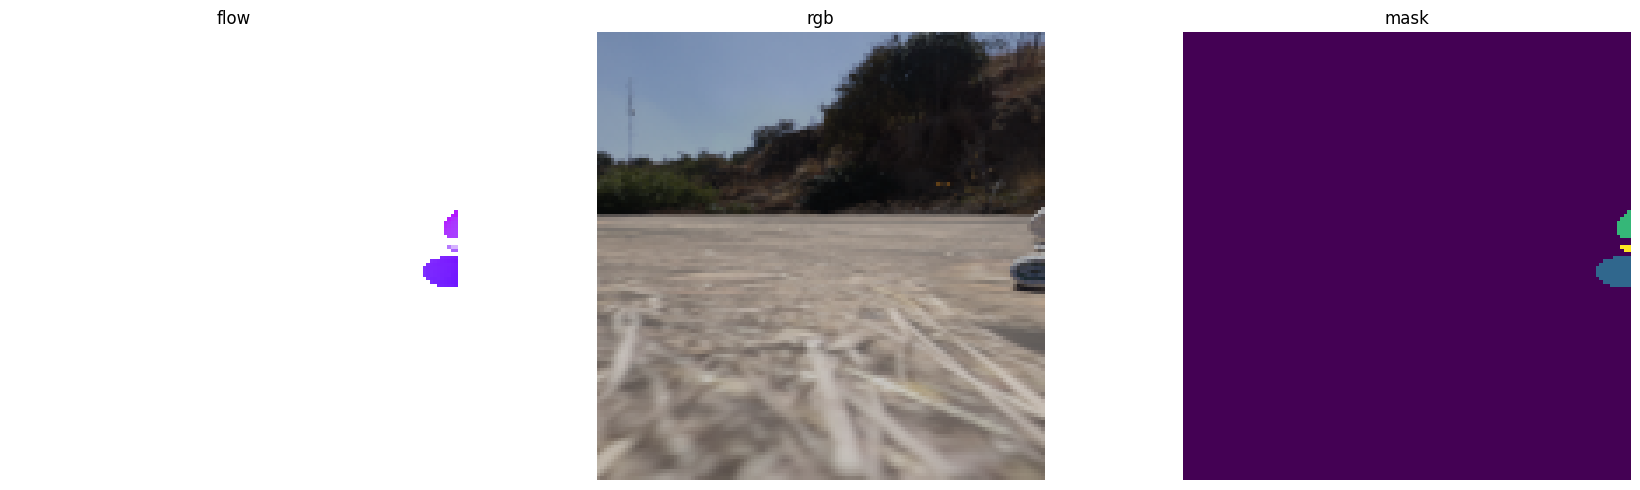

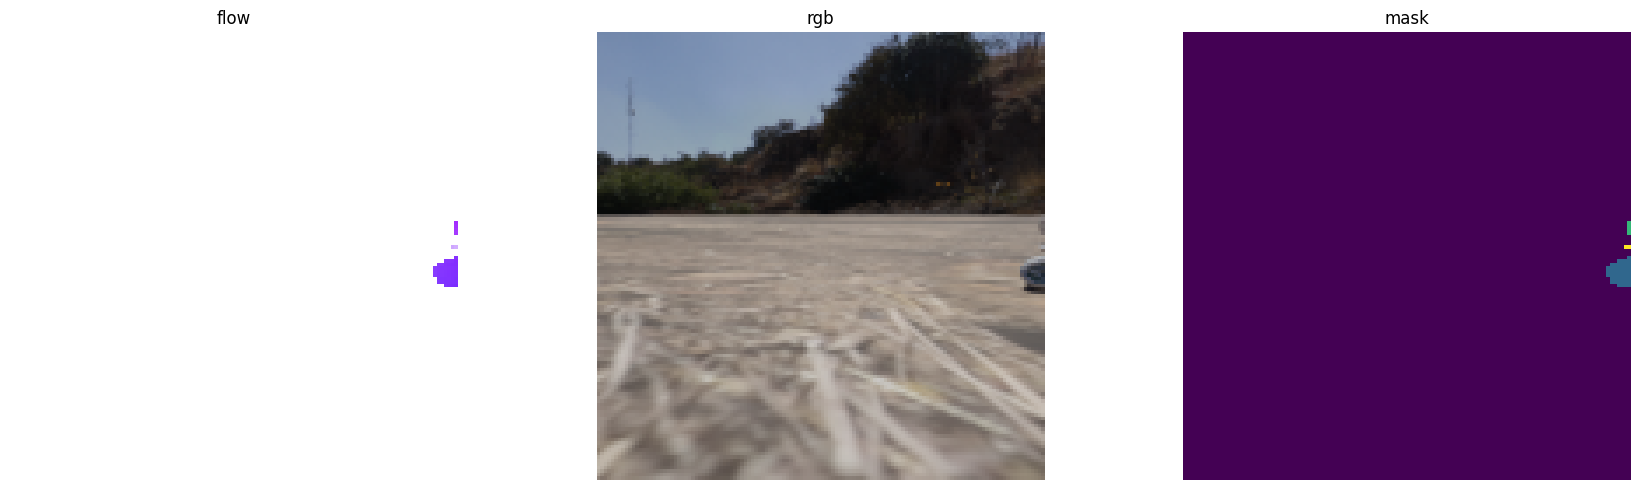

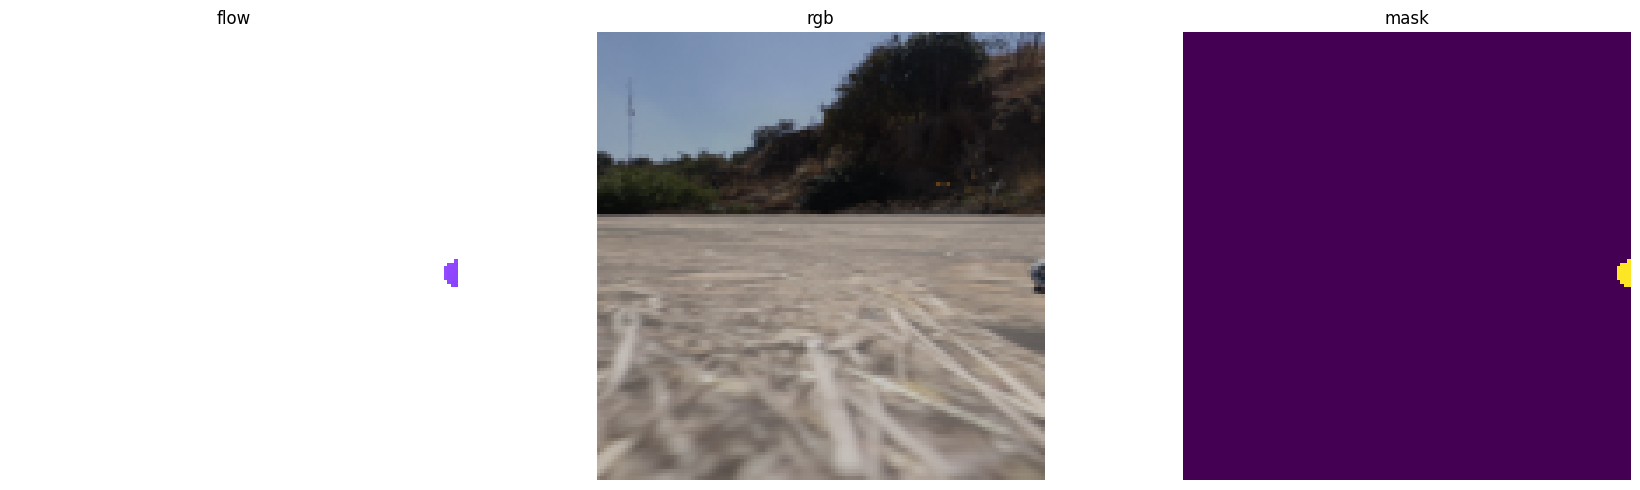

BATCH Video number: 2, read frames count: 24
BATCH Video number: 3, read frames count: 24
BATCH Video number: 4, read frames count: 24
BATCH Video number: 5, read frames count: 24
BATCH Video number: 6, read frames count: 24
BATCH Video number: 7, read frames count: 24
BATCH Video number: 8, read frames count: 24
BATCH Video number: 9, read frames count: 24
BATCH Video number: 10, read frames count: 24
BATCH Video number: 11, read frames count: 24
BATCH Video number: 12, read frames count: 24
BATCH Video number: 13, read frames count: 24
BATCH Video number: 14, read frames count: 24
BATCH Video number: 15, read frames count: 24
BATCH Video number: 16, read frames count: 24
BATCH Video number: 17, read frames count: 24
BATCH Video number: 18, read frames count: 24
BATCH Video number: 19, read frames count: 24
BATCH Video number: 20, read frames count: 24
BATCH Video number: 21, read frames count: 24
BATCH Video number: 22, read frames count: 24
BATCH Video number: 23, read frames count:

In [ ]:
fistVideo=True
for (coords, masks, rgbs, flows) in video_loader:
    movie_count = len(rgbs)
    for i in range (movie_count):   # iterate over batch size, i is video index in the batch.    
        video_frames_data = video_dataset.get_video_frame_labels(coords['com'][i], 
                                                                 coords['bbox'][i], 
                                                                 masks['masks'][i], 
                                                                 rgbs[i], 
                                                                 flows[i])

        if not fistVideo:
            continue
        for frame_index in range(len(video_frames_data)):
            coord, bbox, mask,rgb,flow = video_frames_data[frame_index]
            print(f"Unique values in mask for frame {frame_index}: {mask.unique()}")
            fig, ax = plt.subplots(1, 3)
            fig.set_size_inches(18, 5)
            ax[0].imshow((flow).clamp(0, 255).permute(1,2,0).byte().numpy())
            ax[0].axis("off")
            ax[0].set_title("flow")
            
            ax[1].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
            ax[1].axis("off")
            ax[1].set_title("rgb")
                        
            ax[2].imshow((mask).clamp(0, 255).byte().numpy())
            ax[2].axis("off")
            ax[2].set_title("mask")

            # Please keep in mind that the coord and bbox of each frame is also available here. 

            plt.tight_layout()
            plt.show()
        fistVideo=False